# AdaptiveMath-AI: residual correction and matched ablations

**Hypothesis.** A regularized correction to an HGB anchor can improve probability estimates when a question or a valid content ancestor has sufficient previous response support.

**Inputs:** pre-response features, question identity and valid subject/parent metadata. **Output:** a probability of a correct response. This is a tree-based hybrid with residual memories, not a new deep-learning architecture.

All proposed-model definitions, monthly fitting, inner-fold selection and mechanism diagnostics are located in this notebook. Notebook 03 contains only the HGB and common probability-evaluation definitions; Notebook 06 owns final paired inference. The studied source has already been examined, so these analyses are retrospective technical validation.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions():
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    return pd.concat([pd.read_parquet(path) for path in paths], ignore_index=True)


## Model mechanism

Let \(p_i^{(0)}=f_{\mathrm{HGB80}}(x_i)\). For each valid key \(g\), the memory block supplies

\[
\delta_g=\operatorname{clip}\!\left(
\frac{\sum_{i\in M_g}(y_i-p_i^{(0)})}
{\sum_{i\in M_g}p_i^{(0)}(1-p_i^{(0)})+\lambda_g},
-c_g,c_g\right).
\]

The first supported, enabled route is selected in the order
\(\mathrm{question}\rightarrow\mathrm{subject}\rightarrow\mathrm{parent}\rightarrow0\).
Missing hierarchy keys never form learned pseudo-groups.

\[
p_i^{\mathrm{raw}}=\sigma\!\left(\operatorname{logit}(p_i^{(0)})+\delta_{r(i)}\right),
\qquad
\widehat p_i=C_v\!\left(p_i^{\mathrm{raw}}\right).
\]

This is a one-step regularized residual-logit correction, not a converged optimizer. \(C_v\) is selected and fitted separately for each variant \(v\). Anchor fitting, memory estimation, calibration and evaluation occupy non-overlapping chronological blocks. No gradients through a neural gate are involved.

### Estimate regularized residual memories

In [3]:
%%research_module revision_models
def memory_fit(frame,y,p,column,shrinkage,cap):
    keys=canonical_keys(frame[column])
    valid=keys.notna()
    if column=='parent_subject_id':valid &= frame.primary_subject_id.map(is_valid_subject_id)
    tmp=pd.DataFrame({'key':keys.loc[valid].to_numpy(),
                      'residual':(np.asarray(y)-np.asarray(p))[valid],
                      'hessian':(np.asarray(p)*(1-np.asarray(p)))[valid]})
    agg=tmp.groupby('key').agg(residual=('residual','sum'),hessian=('hessian','sum'),support=('key','size'))
    agg['raw']=agg.residual/(agg.hessian+shrinkage)
    agg['correction']=agg['raw'].clip(-cap,cap)
    return {'delta':agg.correction.to_dict(),'support':agg.support.to_dict(),
            'raw':agg['raw'].to_dict(),'lambda':shrinkage,'cap':cap}



### Fit the enabled memories

In [4]:
%%research_module revision_models
def hierarchy_fit(frame,p,qpar,fpar):
    y=frame.IsCorrect.to_numpy()
    return {name:memory_fit(frame,y,p,col,*par) for name,col,par in [('question','QuestionId',qpar),('subject','primary_subject_id',fpar),('parent','parent_subject_id',fpar)]}



### Apply supported hierarchical routes

In [5]:
%%research_module revision_models
def hierarchy_apply(frame,p,memory,variant='full'):
    delta=np.zeros(len(frame));route=np.full(len(frame),'zero',object)
    support=np.zeros(len(frame),int);lam=np.zeros(len(frame));clipped=np.zeros(len(frame),bool)
    for name,col in [('question','QuestionId'),('subject','primary_subject_id'),('parent','parent_subject_id')]:
        if (variant in ['no_question','hierarchy_only'] and name=='question') or (variant=='question_only' and name!='question') or (variant=='no_subject' and name=='subject'):continue
        keys=canonical_keys(frame[col])
        valid=keys.notna()
        if name=='parent':valid &= frame.primary_subject_id.map(is_valid_subject_id)
        m=memory[name];values=keys.map(m['delta']);take=(route=='zero')&valid.to_numpy()&values.notna().to_numpy()
        delta[take]=values.to_numpy()[take];route[take]=name
        support[take]=keys[take].map(m['support']);lam[take]=m['lambda']
        clipped[take]=keys[take].map(m['raw']).abs()>m['cap']
    return safe_p(expit(logit(safe_p(p))+delta)),pd.DataFrame({'route':route,'support_n':support,
        'shrinkage_lambda':lam,'clipped':clipped,'correction':delta})



### reuse converged helper

In [6]:
%%research_module revision_models
def reuse_converged_helper():
    return fit_converged_ridge_item_intercepts



### Numerical invariants

In [7]:
%%research_module revision_models
def model_tests():
    z=np.array([-.9,.4,1.2]);y=np.array([0.,1.,1.]);lam=2.;d=.13;eps=1e-5
    objective=lambda t:float(np.logaddexp(0,z+t).sum()-y@(z+t)+lam*t*t/2)
    gradient=float((expit(z+d)-y).sum()+lam*d);hessian=float((expit(z+d)*(1-expit(z+d))).sum()+lam)
    assert np.isclose((objective(d+eps)-objective(d-eps))/(2*eps),gradient,rtol=1e-5)
    assert np.isclose((objective(d+eps)-2*objective(d)+objective(d-eps))/eps**2,hessian,rtol=1e-4)
    f=pd.DataFrame({'QuestionId':[1,1,1],'primary_subject_id':[1]*3,'parent_subject_id':[0]*3})
    expected=np.clip((y-expit(z)).sum()/((expit(z)*(1-expit(z))).sum()+lam),-.35,.35)
    # The fixture outcomes are explicit, not real experiment data.
    f['IsCorrect']=y
    memory=hierarchy_fit(f,expit(z),(lam,.35),(200.,.15));assert np.isclose(memory['question']['delta']['1'],expected)
    empty=f.iloc[:0];m=hierarchy_fit(empty,np.array([]),(2.,.35),(200.,.15));p,_=hierarchy_apply(f,expit(z),m);assert np.allclose(p,expit(z))
    return table('model_unit_tests.csv',pd.DataFrame([{'test':x,'status':'PASS','data':'synthetic_unit_test_only'} for x in ['gradient','hessian','first_newton_step','empty_memory_lookup']]),'NB03')



### Chronological inner-fold selection

In [8]:
%%research_module revision_models
def select_inside(frame,seed,outer_fold):
    pr=protocol();dates=np.sort(frame.DateAnswered.unique());trials=[];buffers=[];inner_ids=[]
    for fold,(fi,hi) in enumerate(TimeSeriesSplit(n_splits=pr['inner_folds']).split(dates)):
        fit=frame[frame.DateAnswered.isin(dates[fi])];hold=frame[frame.DateAnswered.isin(dates[hi])]
        result=cached_candidates(fit,hold,seed+fold,seed,outer_fold,fold);buffers.append((hold,result))
        for role,part in [('anchor',next(iter(result.values()))['train']),('memory',next(iter(result.values()))['mem']),('calibration',next(iter(result.values()))['cal']),('holdout',hold)]:
            inner_ids.append(part[KEYS+['DateAnswered']].assign(inner_fold=fold,role=role))
        for l2,r in result.items():
            for name in ['HGB80','HGB100']:
                for cal_name in pr['calibration_candidates']:
                    c=fit_calibrator(cal_name,r[name+'_cal'],r['cal'].IsCorrect)
                    trials.append({'model':name,'l2':l2,'calibration':cal_name,'inner_fold':fold,
                        'Log_Loss':log_loss(hold.IsCorrect,calibrate(c,r[name+'_target']),labels=[0,1]),'stage':'baseline_selection'})
            for name in VARIANT_ROUTES:
                qgrid=[None] if name=='Ablation_no_question' else pr['memory_candidates']
                fgrid=[None] if name=='Question_only' else pr['fallback_candidates']
                for qp in qgrid:
                    for fp in fgrid:
                        sel={'question':qp,'fallback':fp};m=fit_variant_memory(r,sel,name)
                        p,_=raw_variant(hold,r['anchor_target'],m,name)
                        trials.append({'model':name,'l2':l2,'question':json.dumps(qp),'fallback':json.dumps(fp),
                            'inner_fold':fold,'Log_Loss':log_loss(hold.IsCorrect,p,labels=[0,1]),'stage':'component_selection'})
        print(f'Round2 seed={seed} outer={outer_fold+1}/6 inner={fold+1}/4: fitted candidates and variant-specific component scores',flush=True)
    selections={};ledger=pd.DataFrame(trials)
    for name in ['HGB80','HGB100']:
        g=ledger[ledger.model.eq(name)].groupby(['l2','calibration']).Log_Loss.mean().sort_values()
        l2,c=g.index[0];selections[name]={'l2':float(l2),'calibration':c}
    for name in VARIANT_ROUTES:
        g=ledger[ledger.model.eq(name)].groupby(['l2','question','fallback']).Log_Loss.mean().sort_values()
        l2,q,f=g.index[0];selections[name]={'l2':float(l2),'question':json.loads(q),'fallback':json.loads(f)}
    # The mechanism pair uses the same selected HGB80 anchor, not independently selected anchors.
    selections['RecentQuestionRateControl']={'l2':selections['Question_only']['l2'],'alpha':20}
    selections['Converged_item_intercept']={'l2':selections['Question_only']['l2'],'question':selections['Question_only']['question']}
    cal_rows=[]
    for name,sel in selections.items():
        if name in ['HGB80','HGB100']:continue
        for inner,(hold,result) in enumerate(buffers):
            r=result[sel['l2']];m=fit_variant_memory(r,sel,name)
            pc,_=raw_variant(r['cal'],r['anchor_cal'],m,name);ph,_=raw_variant(hold,r['anchor_target'],m,name)
            for family in pr['calibration_candidates']:
                c=fit_calibrator(family,pc,r['cal'].IsCorrect)
                cal_rows.append({'model':name,'inner_fold':inner,'calibration':family,
                    'Log_Loss':log_loss(hold.IsCorrect,calibrate(c,ph),labels=[0,1]),'stage':'independent_calibration_selection'})
        scores=pd.DataFrame(cal_rows);selections[name]['calibration']=scores[scores.model.eq(name)].groupby('calibration').Log_Loss.mean().idxmin()
    ledger=pd.concat([ledger,pd.DataFrame(cal_rows)],ignore_index=True).assign(seed=seed,outer_fold=outer_fold)
    pd.concat(inner_ids,ignore_index=True).to_parquet(artifact_path('Data')/f'round2_inner_ids_seed{seed}_fold{outer_fold}.parquet',index=False)
    return selections,ledger



### prediction frame

In [9]:
%%research_module revision_models
def prediction_frame(frame,p,model,seed,fold,kind,scenario,model_hash,route=None):
    out=frame[KEYS+['IsCorrect','DateAnswered','primary_subject_id','Gender','PremiumPupil','prior_interaction_count']].copy().reset_index(drop=True)
    out=out.rename(columns={'IsCorrect':'y'});out['p']=p;out['model']=model;out['seed']=seed;out['fold']=fold;out['scenario']=scenario;out['prediction_kind']=kind;out['model_hash']=model_hash
    if route is not None: out=pd.concat([out,route.reset_index(drop=True)],axis=1)
    return out



### Fit and freeze each independently calibrated variant

In [10]:
%%research_module revision_models
def fit_frozen(frame,target,selected,seed,fold,features=FEATURES):
    result=fit_candidates(frame,target,seed,features);payload={};predictions=[];fit_ids=[];checks=[]
    selected=dict(selected);selected['No_calibration']={**selected['AdaptiveMath-AI'],'calibration':'none'}
    for name,sel in selected.items():
        r=result[sel['l2']];baseline=name in ['HGB80','HGB100']
        if baseline:
            memory=None;pc=r[name+'_cal'];pt=r[name+'_target'];rt=None;anchor=r[name]
        else:
            memory=fit_variant_memory(r,sel,name);anchor=r['anchor']
            pc,_=raw_variant(r['cal'],r['anchor_cal'],memory,name)
            pt,rt=raw_variant(target,r['anchor_target'],memory,name)
        calibrator=fit_calibrator(sel['calibration'],pc,r['cal'].IsCorrect)
        obj={'anchor':anchor,'memory':memory,'calibrator':calibrator,'features':features,
             'selected':sel,'seed':seed,'fold':fold,'variant':name,'calibration_prediction_hash':object_hash(pc.tolist()),
             'calibration_ids_hash':object_hash(r['cal'].AnswerId.tolist())}
        obj['calibration_hash']=joblib.hash({'variant':name,'calibrator':calibrator,
            'input_predictions':obj['calibration_prediction_hash'],'ids':obj['calibration_ids_hash']})
        path=artifact_path('Models')/f'round2_{name.replace("-","_")}_seed{seed}_fold{fold}.joblib'
        joblib.dump(obj,path);mh=digest(path);restored=joblib.load(path)
        p=calibrate(calibrator,pt);recreated,_=reconstruct(restored,target)
        error=float(np.max(np.abs(p-recreated)));assert error<=1e-12
        out=prediction_frame(target,p,name,seed,fold,'round2_temporal_outer','round2_global_calendar_learner_feedback',mh,rt)
        out['calibration_hash']=obj['calibration_hash'];out['window_start']=target.DateAnswered.min();out['window_end']=target.DateAnswered.max()
        predictions.append(out);payload[name]=obj
        roles=[('anchor',pd.concat([r['train'],r['mem']]) if baseline else r['train']),('calibrator',r['cal'])]
        if not baseline:roles.append(('memory',r['mem']))
        for role,part in roles:
            assert part.DateAnswered.max()<target.DateAnswered.min()
            fit_ids.append(part[KEYS+['DateAnswered']].assign(model=name,component=role,seed=seed,fold=fold))
        checks.append({'seed':seed,'fold':fold,'variant':name,'max_abs_error':error,'status':'PASS',
            'model_hash':mh,'calibration_hash':obj['calibration_hash'],'calibration_rows':len(r['cal']),
            'target_rows':len(target),'calibration_method':calibrator['name'],'selected':json.dumps(sel,sort_keys=True),
            'anchor_min':str(roles[0][1].DateAnswered.min()),'anchor_max':str(roles[0][1].DateAnswered.max()),
            'memory_min':str(r['mem'].DateAnswered.min()),'memory_max':str(r['mem'].DateAnswered.max()),
            'calibration_min':str(r['cal'].DateAnswered.min()),'calibration_max':str(r['cal'].DateAnswered.max())})
        print(f'Round2 seed={seed} window={fold+1}/6 variant={name}: refit, saved, reconstruction PASS',flush=True)
    return pd.concat(predictions,ignore_index=True),pd.concat(fit_ids,ignore_index=True),pd.DataFrame(checks),payload



### Monthly experiment driver

In [11]:
%%research_module revision_models
def primary_experiment():
    pr=protocol();frame=pd.read_parquet(artifact_path('Data/features_primary.parquet'))
    frame=frame[frame.split.ne('representation')].reset_index(drop=True)
    edges=pd.to_datetime(pr['calendar']['outer_edges'],utc=True);assert len(edges)==7
    design={'budget':{'seeds':10,'outer':6,'inner':4},'outer_edges':list(map(str,edges)),
        'outer_fit_rule':'Strictly earlier completed events; 60/20/20 anchor/memory/calibration by unique timestamps.',
        'inner_rule':'Four expanding time folds; independently selected component parameters and calibrators.',
        'primary_estimand':'Equal-window macro mean of six within-window AUC differences.',
        'mechanism_pair':'Question_only and RecentQuestionRateControl share the selected HGB80 anchor and memory block.'}
    save_json(artifact_path('temporal_design.json'),design)
    inputs=[artifact_path('Data/features_primary.parquet'),artifact_path('Data/split_manifest.parquet'),
            artifact_path('revision_protocol.json'),artifact_path('feature_contract.json')]
    base_hash={str(p.relative_to(V)):digest(p) for p in inputs}
    base_hash['revision_models.py']=code_digest(__name__);summaries=[];started=time.monotonic()
    with threadpool_limits(limits=4):
        for seed in pr['seeds']:
            for fold,(start,end) in enumerate(zip(edges[:-1],edges[1:])):
                out=artifact_path('Data')/f'round2_predictions_seed{seed}_fold{fold}.parquet'
                meta=artifact_path('manifests')/f'round2_fit_seed{seed}_fold{fold}.json'
                contract=dict(input_code_helper_feature_split_hashes=base_hash,data_helper_hash=code_digest('revision_data'),seed=seed,fold=fold,start=str(start),end=str(end))
                if out.exists() and meta.exists():
                    cached=json.loads(meta.read_text())
                    if cached['contract']!=contract or cached['prediction_hash']!=digest(out):raise RuntimeError('Stale Round2 cache; do not mix dependencies')
                    for rel,h in cached['models'].items():assert digest(ROOT/rel)==h
                    summaries+=cached['summary'];print(f'Exact Round2 cache seed={seed} window={fold+1}/6',flush=True);continue
                fit=frame[frame.DateAnswered<start];target=frame[(frame.DateAnswered>=start)&(frame.DateAnswered<end)]
                assert not target.empty and fit.DateAnswered.max()<start
                print(f'Round2 START seed={seed} window={fold+1}/6 fit={len(fit)} target={len(target)} elapsed={time.monotonic()-started:.1f}s',flush=True)
                selected,ledger=select_inside(fit,seed,fold)
                preds,ids,checks,payload=fit_frozen(fit,target,selected,seed,fold)
                preds.to_parquet(out,index=False)
                ids.to_parquet(artifact_path('Data')/f'round2_fitting_ids_seed{seed}_fold{fold}.parquet',index=False)
                ledger.to_parquet(artifact_path('Tables')/f'round2_tuning_seed{seed}_fold{fold}.parquet',index=False)
                checks.to_csv(artifact_path('Tables')/f'round2_reconstruction_seed{seed}_fold{fold}.csv',index=False)
                current=[{'seed':seed,'fold':fold,'model':name,'N':len(g),**metrics(g.y,g.p)} for name,g in preds.groupby('model')]
                models={str(p.relative_to(ROOT)):digest(p) for p in artifact_path('Models').glob(f'round2_*seed{seed}_fold{fold}.joblib')}
                save_json(meta,{'contract':contract,'selected':selected,'models':models,
                    'calibration_hashes':{k:v['calibration_hash'] for k,v in payload.items()},
                    'prediction_hash':digest(out),'fitting_ids_hash':digest(artifact_path('Data')/f'round2_fitting_ids_seed{seed}_fold{fold}.parquet'),'summary':current})
                summaries+=current;table('round2_primary_per_seed_window_metrics.csv',pd.DataFrame(summaries),'NB05')
                print(f'Round2 COMPLETED seed={seed} window={fold+1}/6 elapsed={time.monotonic()-started:.1f}s',flush=True)
    return pd.DataFrame(summaries).groupby('model')[['ROC_AUC','Log_Loss','Brier','ECE15']].agg(['mean','std'])



### Missing-key and fallback tests

In [12]:
%%research_module revision_models
def hierarchy_tests():
    fit=pd.DataFrame({'QuestionId':[1,2,3,4,5,6,7,8,9],
        'primary_subject_id':[10,10,None,-1,'−1','nan','NaN',pd.NA,20],
        'parent_subject_id':[100,None,None,-1,'−1','nan','NaN',pd.NA,200],
        'IsCorrect':[1,0,1,1,0,1,0,1,1]})
    memory=hierarchy_fit(fit,np.full(len(fit),.5),(2.,.35),(50.,.15))
    target=pd.DataFrame({'QuestionId':[1,90,3,91,92,93],
        'primary_subject_id':[10,10,None,None,30,'nan'],
        'parent_subject_id':[100,None,None,100,100,'nan']})
    p,rt=hierarchy_apply(target,np.full(len(target),.5),memory)
    rt['case']=['A_valid_question','B_valid_subject_missing_parent','C_question_missing_subject',
                'D_unsupported_missing_subject','valid_parent_fallback','E_string_sentinel']
    rt['expected_route']=['question','subject','question','zero','parent','zero']
    rt['status']=np.where(rt.route.eq(rt.expected_route),'PASS','FAIL')
    assert rt.status.eq('PASS').all()
    for name in ['subject','parent']:
        assert all(is_valid_subject_id(k) for k in memory[name]['delta'])
    from revision_data import EventReplay
    events=fit.assign(AnswerId=np.arange(len(fit)),UserId=1,subject_depth=np.nan,
        DateAnswered=pd.date_range('2018-09-01',periods=len(fit),tz='UTC'))
    state=EventReplay();state.run(events)
    assert all(is_valid_subject_id(k) for k in state.subjects)
    assert all(is_valid_subject_id(k) for k in state.learner(1)[4])
    return table('round2_hierarchy_unit_tests.csv',rt,'NB02')



### Fit the matched recent-item-rate control

In [13]:
%%research_module revision_models
def recent_rate_fit(frame):
    valid=frame.QuestionId.map(normalize_id).notna();d=frame.loc[valid]
    base=float(d.IsCorrect.mean());g=d.groupby('QuestionId').IsCorrect.agg(['sum','size'])
    rate=(g['sum']+20*base)/(g['size']+20)
    delta=logit(safe_p(rate))-logit(safe_p([base]))[0]
    return {'global_rate':base,'alpha':20,'delta':{str(int(k)):float(v) for k,v in zip(g.index,delta)},
            'support':{str(int(k)):int(v) for k,v in g['size'].items()}}



### Apply the matched recent-rate control

In [14]:
%%research_module revision_models
def recent_rate_apply(frame,p,memory):
    keys=canonical_keys(frame.QuestionId)
    d=keys.map(memory['delta']).fillna(0).to_numpy()
    rt=pd.DataFrame({'route':np.where(keys.isin(memory['delta']),'recent_question_rate','zero'),
        'support_n':keys.map(memory['support']).fillna(0).to_numpy(int),'correction':d})
    return safe_p(expit(logit(safe_p(p))+d)),rt



### Converged item-intercept comparator

In [15]:
%%research_module revision_models
def fit_converged_ridge_item_intercepts(frame,labels,anchor,column="question_id",shrinkage=2.0,max_iter=50,tolerance=1e-8):
 keys=frame[column].astype(str); codes,levels=pd.factorize(keys,sort=True); offsets=logit(safe_p(anchor)); intercepts=np.zeros(len(levels),dtype=float)
 for iteration in range(max_iter):
  probability=expit(offsets+intercepts[codes]); gradient=np.bincount(codes,weights=labels-probability,minlength=len(levels))-shrinkage*intercepts; curvature=np.bincount(codes,weights=probability*(1-probability),minlength=len(levels))+shrinkage; step=gradient/np.maximum(curvature,1e-12); intercepts+=step
  if np.max(np.abs(step))<tolerance: break
 return dict(zip(levels.astype(str),intercepts)),iteration+1

VARIANT_ROUTES={'AdaptiveMath-AI':'full','Ablation_no_question':'no_question',
                'Ablation_no_subject':'no_subject','Question_only':'question_only'}



### Variant-specific residual mechanisms

In [16]:
%%research_module revision_models
def fit_variant_memory(r,sel,name):
    if name=='RecentQuestionRateControl':return recent_rate_fit(r['mem'])
    if name=='Converged_item_intercept':
        m,it=fit_converged_ridge_item_intercepts(r['mem'],r['mem'].IsCorrect.to_numpy(),
            r['anchor_mem'],column='QuestionId',shrinkage=sel['question'][0])
        return {'delta':{k:float(np.clip(v,-sel['question'][1],sel['question'][1])) for k,v in m.items()},
                'iterations':it,'support':r['mem'].QuestionId.astype(str).value_counts().to_dict()}
    route=VARIANT_ROUTES.get(name,'full');out={}
    for level,col in [('question','QuestionId'),('subject','primary_subject_id'),('parent','parent_subject_id')]:
        enabled=not ((route=='no_question' and level=='question') or (route=='no_subject' and level=='subject') or (route=='question_only' and level!='question'))
        par=sel.get('question') if level=='question' else sel.get('fallback')
        cache=r.setdefault('_component_cache',{})
        if enabled:
            key=(level,tuple(par))
            if key not in cache:cache[key]=memory_fit(r['mem'],r['mem'].IsCorrect.to_numpy(),r['anchor_mem'],col,*par)
            out[level]=cache[key]
        else:out[level]={'delta':{},'support':{},'raw':{},'lambda':0.,'cap':0.}
    return out



### Variant prediction before calibration

In [17]:
%%research_module revision_models
def raw_variant(frame,p,memory,name):
    if name in ['RecentQuestionRateControl','Converged_item_intercept']:
        values,route=recent_rate_apply(frame,p,memory)
        if name=='Converged_item_intercept':route['route']=route['route'].replace({'recent_question_rate':'question'})
        return values,route
    return hierarchy_apply(frame,p,memory,VARIANT_ROUTES.get(name,'full'))



### Reconstruct probabilities from frozen components

In [18]:
%%research_module revision_models
def reconstruct(obj,frame):
    p=predict(obj['anchor'],frame,obj['features']);rt=None
    if obj['memory'] is not None:p,rt=raw_variant(frame,p,obj['memory'],obj['variant'])
    return calibrate(obj['calibrator'],p),rt


### canonical keys

In [19]:
%%research_module revision_models
def canonical_keys(series):
    numeric=pd.to_numeric(series,errors='coerce')
    valid=numeric.notna() & numeric.ge(0) & np.isfinite(numeric) & numeric.eq(np.floor(numeric))
    out=pd.Series(None,index=series.index,dtype=object)
    out.loc[valid]=numeric.loc[valid].astype('int64').astype(str)
    return out

### Imports and constants

In [20]:
%%research_module revision_provenance
"""Frozen-component reconstruction and compact prediction provenance."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import json
import joblib
import numpy as np
import pandas as pd
from scipy.special import expit,logit
from threadpoolctl import threadpool_limits
from revision_data import V,KEYS,protocol,digest,save_json,table,object_hash
from revision_models import predict,calibrate,hierarchy_apply,reuse_converged_helper,safe_p



### component provenance

In [21]:
%%research_module revision_provenance
@threadpool_limits.wrap(limits=4)
def component_provenance():
    features=pd.read_parquet(artifact_path('Data/features_primary.parquet')).set_index('AnswerId',drop=False)
    records=[];routes=[];fits=[];helper=reuse_converged_helper()
    for path in sorted((artifact_path('Data')).glob('predictions_seed*_fold*.parquet')):
        pred=pd.read_parquet(path);seed=int(pred.seed.iloc[0]);fold=int(pred.fold.iloc[0])
        ids=pd.read_parquet(artifact_path('Data')/f'fitting_ids_seed{seed}_fold{fold}.parquet')
        ap=artifact_path('Models')/f'AdaptiveMath_AI_seed{seed}_fold{fold}.joblib';obj=joblib.load(ap)
        target=features.loc[pred.loc[pred.model.eq('AdaptiveMath-AI'),'AnswerId']].reset_index(drop=True)
        anchor=predict(obj['anchor'],target);memids=ids[(ids.model=='AdaptiveMath-AI')&(ids.component=='memory')].AnswerId
        mem=features.loc[memids].reset_index(drop=True);mp=predict(obj['anchor'],mem)
        corrections,iterations=helper(mem.rename(columns={'QuestionId':'question_id'}),mem.IsCorrect.to_numpy(),mp,shrinkage=obj['selected']['question'][0])
        cp=artifact_path('Models')/f'converged_parameters_seed{seed}_fold{fold}.joblib'
        joblib.dump({'delta':corrections,'iterations':iterations,'lambda':obj['selected']['question'][0],'cap':obj['selected']['question'][1],'parent_model_hash':digest(ap),'memory_ids_hash':object_hash(memids.tolist())},cp)
        for name,g in pred.groupby('model',sort=False):
            recipe={'variant':name,'parent_model_hash':g.model_hash.iloc[0],'calibration':'none','memory_variant':'none'}
            route=None
            if name in ['HGB80','HGB100']:
                own=joblib.load(artifact_path('Models')/f'{name}_seed{seed}_fold{fold}.joblib')
                p=calibrate(own['calibrator'],predict(own['anchor'],target));recipe['calibration']=joblib.hash(own['calibrator'])
            elif name=='HGB80_anchor':p=anchor
            elif name=='Converged_item_intercept':
                delta=target.QuestionId.astype(str).map(corrections).fillna(0).clip(-obj['selected']['question'][1],obj['selected']['question'][1]).to_numpy()
                p=safe_p(expit(logit(anchor)+delta));recipe['converged_parameters_hash']=digest(cp)
            else:
                variant={'Plus_question_memory':'question_only','Ablation_no_question':'no_question','Ablation_no_subject':'no_subject'}.get(name,'full')
                p,route=hierarchy_apply(target,anchor,obj['memory'],variant);recipe['memory_variant']=variant
                if name in ['AdaptiveMath-AI','Ablation_no_question','Ablation_no_subject']:
                    p=calibrate(obj['calibrator'],p);recipe['calibration']=joblib.hash(obj['calibrator'])
            # Target order is fixed in all variant frames; check IDs explicitly.
            assert np.array_equal(g.AnswerId.to_numpy(),target.AnswerId.to_numpy())
            np.testing.assert_allclose(p,g.p.to_numpy(),rtol=0,atol=1e-12)
            rid=object_hash(recipe)
            records.append({'prediction_file':str(path.relative_to(V)),'file_sha256':digest(path),'model':name,'seed':seed,'fold':fold,'N':len(g),'prediction_kind':g.prediction_kind.iloc[0],'model_hash_semantics':'frozen object' if name in ['AdaptiveMath-AI','HGB80','HGB100'] else 'parent frozen object plus explicit reconstruction recipe','recipe_hash':rid,'recipe':json.dumps(recipe,sort_keys=True),'reloaded_prediction_max_error':float(np.max(np.abs(p-g.p.to_numpy())))})
            if route is not None:
                for route_name,r in route.groupby('route'):
                    routes.append({'model':name,'seed':seed,'fold':fold,'route':route_name,'N':len(r),'route_fraction':len(r)/len(route),'support_median':r.support_n.median(),'support_min':r.support_n.min(),'support_max':r.support_n.max(),'clipped_fraction':r.clipped.mean(),'mean_abs_correction':r.correction.abs().mean(),'shrinkage_lambda':r.shrinkage_lambda.iloc[0]})
        for (name,component),g in ids.groupby(['model','component']):
            assert g.DateAnswered.max()<target.DateAnswered.min()
            fits.append({'model':name,'seed':seed,'fold':fold,'component':component,'fit_rows':len(g),'fit_start':g.DateAnswered.min(),'fit_end':g.DateAnswered.max(),'evaluation_start':target.DateAnswered.min(),'exact_ids_path':str((artifact_path('Data')/f'fitting_ids_seed{seed}_fold{fold}.parquet').relative_to(V))})
        print(f'Frozen component reconstruction verified: seed={seed}, fold={fold}',flush=True)
    table('prediction_component_provenance.csv',pd.DataFrame(records),'NB06')
    table('component_fitting_provenance.csv',pd.DataFrame(fits),'NB06')
    table('route_support_diagnostics.csv',pd.DataFrame(routes),'NB06')
    return pd.DataFrame(records).groupby('model').agg(folds=('fold','size'),maximum_reload_error=('reloaded_prediction_max_error','max')).reset_index()

## Matched alternatives and tuning opportunities
Removing a component changes the model's permitted routes. It does not reuse the full model's selected calibrator. The converged item-intercept comparator and the recent-rate control share the Question_only anchor and memory/calibration IDs.

In [22]:
import revision_models as rm
variants=pd.DataFrame([
    ("AdaptiveMath-AI","question → subject → parent → zero","selected independently"),
    ("Ablation_no_question","subject → parent → zero","selected independently"),
    ("Ablation_no_subject","question → parent → zero","selected independently"),
    ("Question_only","question → zero","selected independently"),
    ("RecentQuestionRateControl","smoothed recent item rate; α=20","selected independently"),
    ("Converged_item_intercept","converged ridge item offset","selected independently"),
    ("No_calibration","full residual route","identity mapping")],columns=["Variant","Mechanism","Calibration"])
show_table(variants,"Variants and independent calibration",["Variant"],width=2)
pr=rd.protocol()
search=pd.DataFrame([{"Parameter":"L2 anchor penalty","Candidates":str(pr["hgb"]["l2_candidates"])},
    {"Parameter":"Question (λ, cap)","Candidates":str(pr["memory_candidates"])},
    {"Parameter":"Fallback (λ, cap)","Candidates":str(pr["fallback_candidates"])},
    {"Parameter":"Calibration","Candidates":", ".join(pr["calibration_candidates"])},
    {"Parameter":"Budget","Candidates":"10 seeds × 6 monthly windows × 4 expanding inner folds"}])
show_table(search,"Fixed search space",["Parameter"],width=1)

**Variants and independent calibration**

Variant,Mechanism,Calibration
AdaptiveMath-AI,question → subject → parent → zero,selected independently
Ablation_no_question,subject → parent → zero,selected independently
Ablation_no_subject,question → parent → zero,selected independently
Question_only,question → zero,selected independently
RecentQuestionRateControl,smoothed recent item rate; α=20,selected independently
Converged_item_intercept,converged ridge item offset,selected independently
No_calibration,full residual route,identity mapping


**Fixed search space**

Parameter,Candidates
L2 anchor penalty,"[1.0, 2.0]"
"Question (λ, cap)","[[2.0, 0.35], [5.0, 0.35], [5.0, 0.5], [10.0, 0.35], [20.0, 0.35]]"
"Fallback (λ, cap)","[[50.0, 0.15], [100.0, 0.15], [200.0, 0.15], [200.0, 0.3], [500.0, 0.15]]"
Calibration,"none, temperature, platt"
Budget,10 seeds × 6 monthly windows × 4 expanding inner folds


## Fitting and frozen-object reconstruction
The following cell executes the visible fitting driver. Exact compatible caches are reused; changed inputs or code are rejected. The training logs are not scientific results and are captured rather than left as long notebook outputs.

In [23]:
with capture_output():
    rm.model_tests()
    rm.hierarchy_tests()
    fitted_summary=rm.primary_experiment()
    import round2_analysis as r2
    recipe_checks=r2.verify_prediction_recipes()
assert recipe_checks.status.eq("PASS").all()

## Selected configurations across all seeds and windows
The table reports how often each complete configuration was selected. Counts describe fitted configurations, not independent statistical replications.

In [3]:
checks=pd.concat([pd.read_csv(p) for p in sorted(artifact_path("Tables").glob("round2_reconstruction_seed*_fold*.csv"))],ignore_index=True)
assert len(checks)==540 and checks.max_abs_error.le(1e-12).all()
rows=[]
for row in checks.itertuples(index=False):
    selected=json.loads(row.selected)
    question=selected.get("question") or [None,None]
    fallback=selected.get("fallback") or [None,None]
    rows.append({"Variant":row.variant,"Anchor L2":selected["l2"],
        "Question λ":question[0],"Question cap":question[1],
        "Fallback λ":fallback[0],"Fallback cap":fallback[1],
        "Calibration":row.calibration_method,"Seed":row.seed,"Window":row.fold})
choices=pd.DataFrame(rows)
keys=["Variant","Anchor L2","Question λ","Question cap","Fallback λ","Fallback cap","Calibration"]
configurations=choices.groupby(keys,dropna=False).agg(Fits=("Seed","size"),Windows=("Window","nunique"),Seeds=("Seed","nunique")).reset_index()
configurations.insert(0,"Configuration",np.arange(1,len(configurations)+1))
parameter_columns=["Question λ","Question cap","Fallback λ","Fallback cap"]
configurations[parameter_columns]=configurations[parameter_columns].astype(object).where(configurations[parameter_columns].notna(),"Not applicable")
show_table(configurations,"All selected model configurations",["Configuration","Variant"],width=3,rows=10)

**All selected model configurations**

Configuration,Variant,Anchor L2,Question λ,Question cap
1,Ablation_no_question,2,Not applicable,Not applicable
2,Ablation_no_question,2,Not applicable,Not applicable
3,Ablation_no_question,2,Not applicable,Not applicable
4,Ablation_no_question,2,Not applicable,Not applicable
5,Ablation_no_subject,2,5,0.5
6,Ablation_no_subject,2,5,0.5
7,Ablation_no_subject,2,5,0.5
8,AdaptiveMath-AI,2,5,0.5
9,AdaptiveMath-AI,2,5,0.5
10,AdaptiveMath-AI,2,5,0.5


Configuration,Variant,Fallback λ,Fallback cap,Calibration
1,Ablation_no_question,100,0.15,none
2,Ablation_no_question,100,0.15,platt
3,Ablation_no_question,200,0.3,none
4,Ablation_no_question,200,0.3,platt
5,Ablation_no_subject,200,0.3,none
6,Ablation_no_subject,500,0.15,none
7,Ablation_no_subject,500,0.15,platt
8,AdaptiveMath-AI,100,0.15,none
9,AdaptiveMath-AI,200,0.3,none
10,AdaptiveMath-AI,200,0.3,platt


Configuration,Variant,Fits,Windows,Seeds
1,Ablation_no_question,30,3,10
2,Ablation_no_question,10,1,10
3,Ablation_no_question,10,1,10
4,Ablation_no_question,10,1,10
5,Ablation_no_subject,10,1,10
6,Ablation_no_subject,40,4,10
7,Ablation_no_subject,10,1,10
8,AdaptiveMath-AI,20,2,10
9,AdaptiveMath-AI,10,1,10
10,AdaptiveMath-AI,10,1,10


Configuration,Variant,Anchor L2,Question λ,Question cap
11,AdaptiveMath-AI,2,5,0.5
12,Converged_item_intercept,2,5,0.5
13,Converged_item_intercept,2,5,0.5
14,HGB100,1,Not applicable,Not applicable
15,HGB100,2,Not applicable,Not applicable
16,HGB100,2,Not applicable,Not applicable
17,HGB80,1,Not applicable,Not applicable
18,HGB80,2,Not applicable,Not applicable
19,No_calibration,2,5,0.5
20,No_calibration,2,5,0.5


Configuration,Variant,Fallback λ,Fallback cap,Calibration
11,AdaptiveMath-AI,500,0.15,none
12,Converged_item_intercept,Not applicable,Not applicable,none
13,Converged_item_intercept,Not applicable,Not applicable,platt
14,HGB100,Not applicable,Not applicable,none
15,HGB100,Not applicable,Not applicable,none
16,HGB100,Not applicable,Not applicable,platt
17,HGB80,Not applicable,Not applicable,none
18,HGB80,Not applicable,Not applicable,none
19,No_calibration,100,0.15,none
20,No_calibration,200,0.3,none


Configuration,Variant,Fits,Windows,Seeds
11,AdaptiveMath-AI,20,2,10
12,Converged_item_intercept,50,5,10
13,Converged_item_intercept,10,1,10
14,HGB100,20,2,10
15,HGB100,30,3,10
16,HGB100,10,1,10
17,HGB80,10,1,10
18,HGB80,50,5,10
19,No_calibration,20,2,10
20,No_calibration,20,2,10


Configuration,Variant,Anchor L2,Question λ,Question cap
21,No_calibration,2,5,0.5
22,Question_only,2,5,0.5
23,Question_only,2,5,0.5
24,RecentQuestionRateControl,2,Not applicable,Not applicable
25,RecentQuestionRateControl,2,Not applicable,Not applicable


Configuration,Variant,Fallback λ,Fallback cap,Calibration
21,No_calibration,500,0.15,none
22,Question_only,Not applicable,Not applicable,none
23,Question_only,Not applicable,Not applicable,platt
24,RecentQuestionRateControl,Not applicable,Not applicable,none
25,RecentQuestionRateControl,Not applicable,Not applicable,platt


Configuration,Variant,Fits,Windows,Seeds
21,No_calibration,20,2,10
22,Question_only,50,5,10
23,Question_only,10,1,10
24,RecentQuestionRateControl,50,5,10
25,RecentQuestionRateControl,10,1,10


## Inner-fold component sensitivity
All 5 × 5 residual-memory candidates are displayed for each anchor L2 value. Values are means of inner-holdout log loss over seeds and monthly fitting windows before variant-specific calibration. This is a tuning diagnostic, not final-test evidence and not an epoch learning curve.

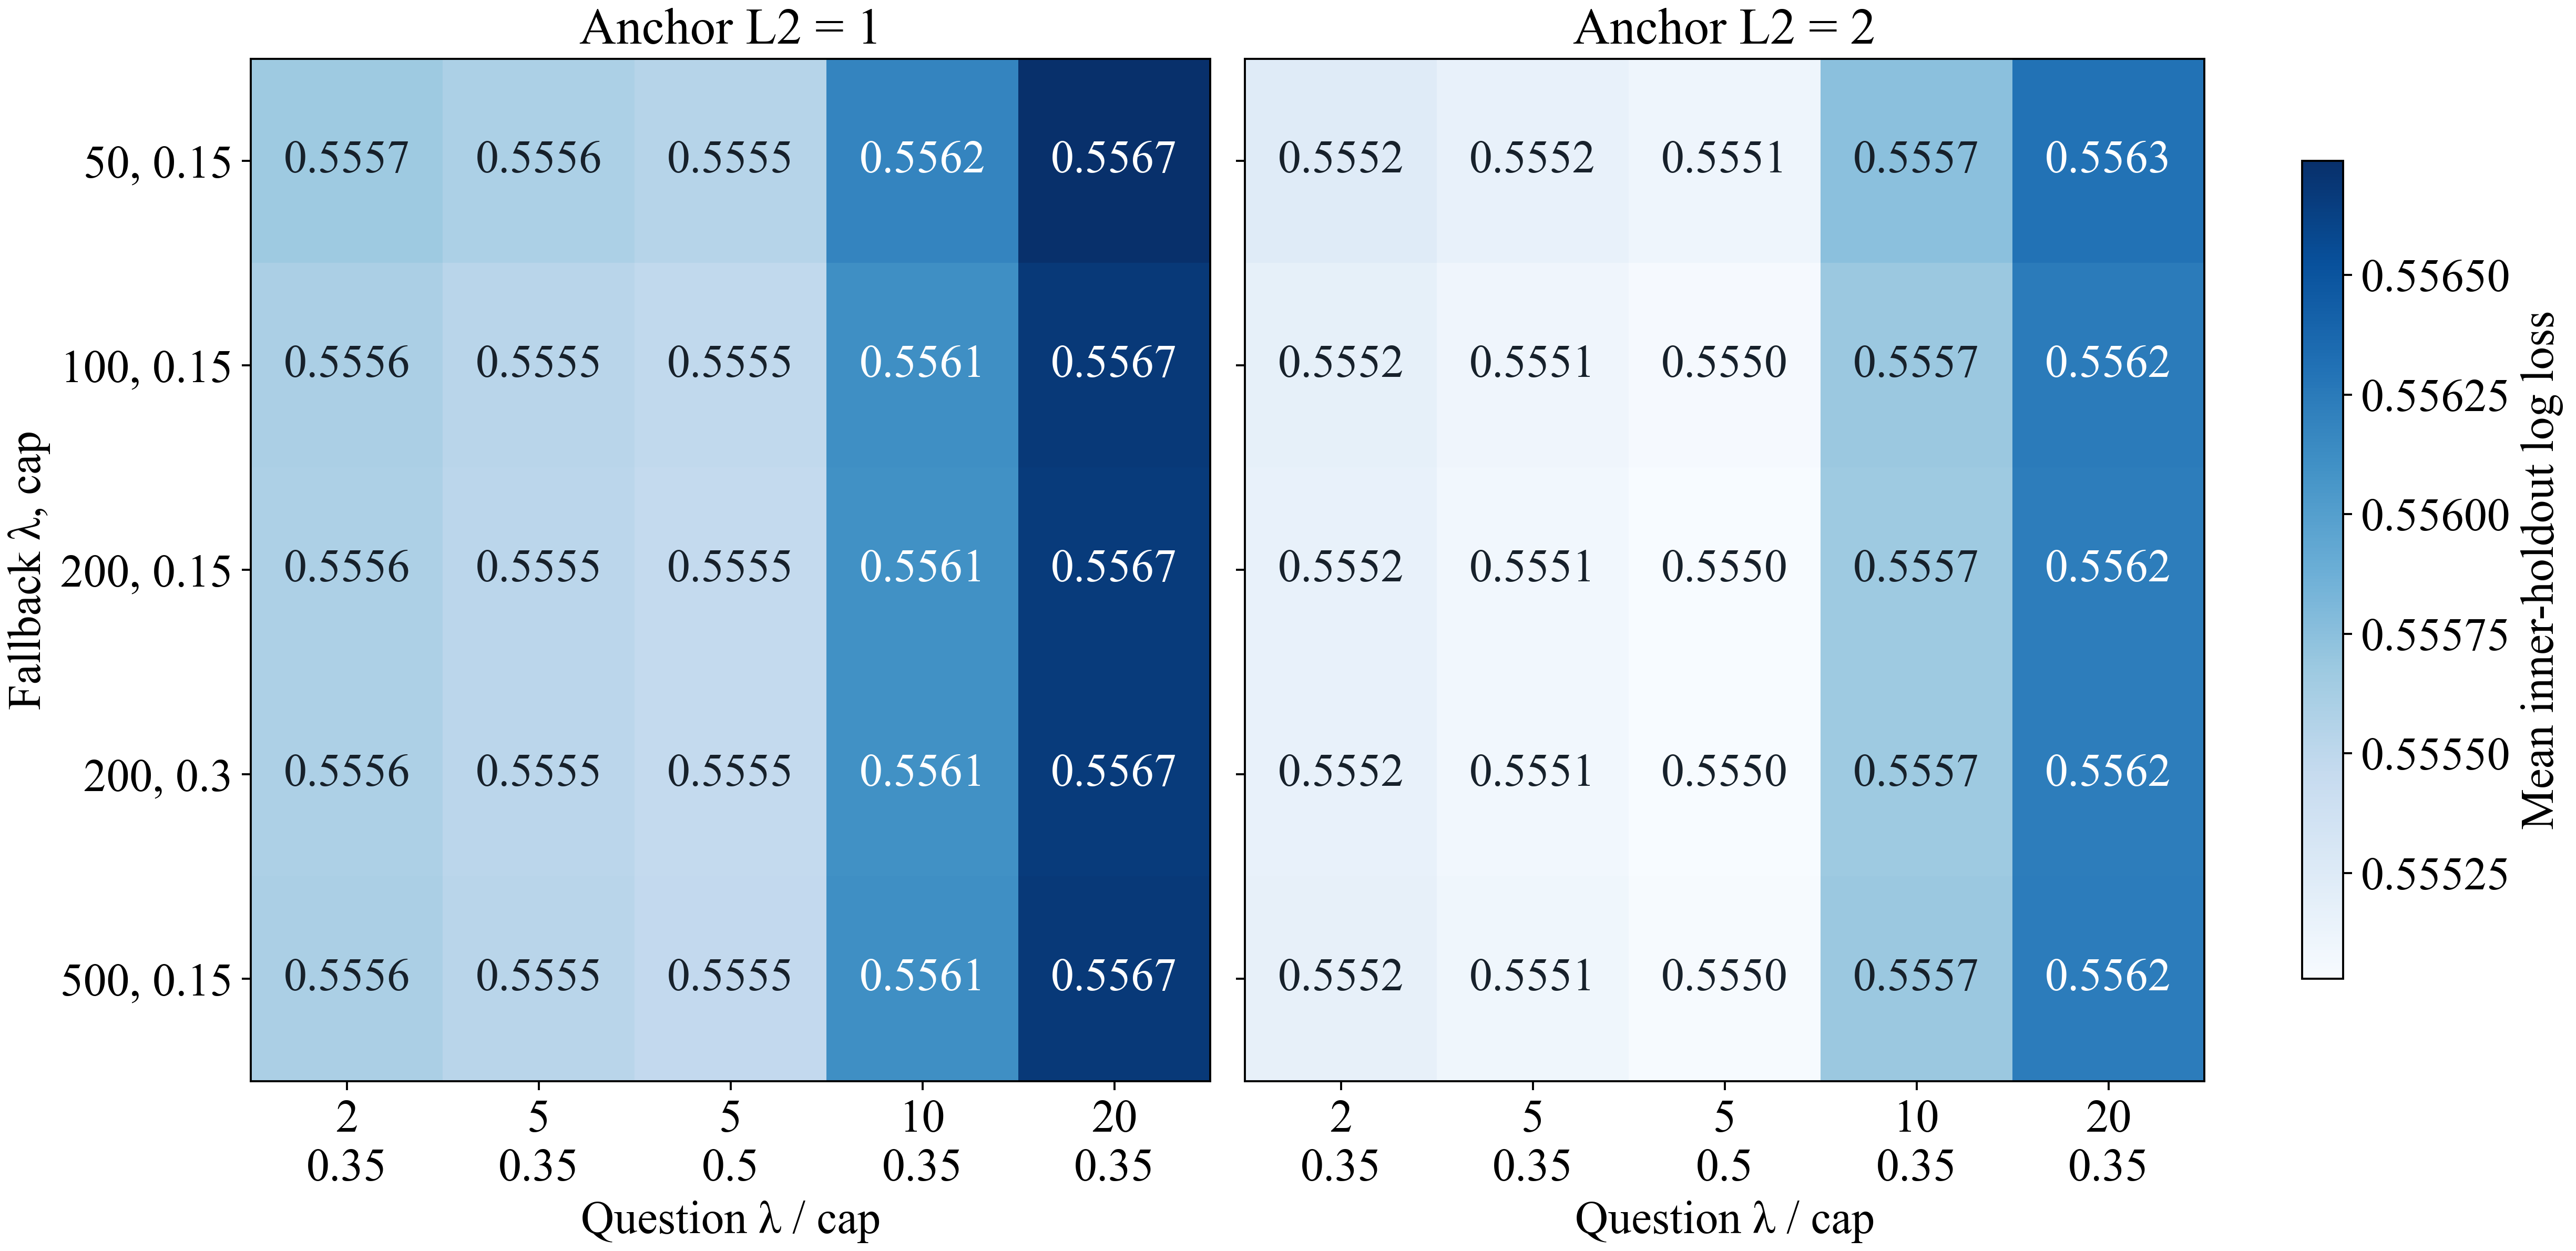

In [25]:
trials=pd.concat([pd.read_parquet(p) for p in sorted(artifact_path("Tables").glob("round2_tuning_seed*_fold*.parquet"))],ignore_index=True)
sensitivity=trials[(trials.model=="AdaptiveMath-AI") & (trials.stage=="component_selection")]
qkeys=[json.dumps(x) for x in pr["memory_candidates"]]
fkeys=[json.dumps(x) for x in pr["fallback_candidates"]]
matrices=[]
for l2 in pr["hgb"]["l2_candidates"]:
    matrix=sensitivity[sensitivity.l2.eq(l2)].groupby(["fallback","question"]).Log_Loss.mean().unstack().reindex(index=fkeys,columns=qkeys)
    assert matrix.notna().all().all()
    matrices.append(matrix)
vmin=min(m.to_numpy().min() for m in matrices);vmax=max(m.to_numpy().max() for m in matrices)
fig,axes=plt.subplots(1,2,figsize=(14,6.8),layout="constrained",sharey=True)
for ax,l2,matrix in zip(axes,pr["hgb"]["l2_candidates"],matrices):
    im=ax.imshow(matrix,cmap="Blues",vmin=vmin,vmax=vmax,aspect="auto")
    ax.set_xticks(range(5),[f"{v[0]:g}\n{v[1]:g}" for v in pr["memory_candidates"]])
    ax.set_yticks(range(5),[f"{v[0]:g}, {v[1]:g}" for v in pr["fallback_candidates"]])
    ax.set_xlabel("Question λ / cap");ax.set_title(f"Anchor L2 = {l2:g}")
    for i in range(5):
        for j in range(5):
            value=matrix.iloc[i,j];tone="white" if (value-vmin)/max(vmax-vmin,1e-12)>.6 else "#17212B"
            ax.text(j,i,f"{value:.4f}",ha="center",va="center",color=tone,fontsize=18)
axes[0].set_ylabel("Fallback λ, cap")
fig.colorbar(im,ax=axes,label="Mean inner-holdout log loss",shrink=.8)
save_canvas(fig,"adaptive_math_inner_sensitivity")

## Development-block route support and corrections
The first prespecified seed is used to inspect the frozen model's routes on its earlier calibration block. These descriptive mechanism summaries are not calibration-quality estimates: the same block fitted the calibration mapping. Evaluation responses and labels are not used here.

**Route usage and support by monthly window**

fold,route,N,Median_support,Minimum_support,Maximum_support
0,parent,38,296,6,3209
0,question,25379,3,1,28
0,subject,9757,280,1,1122
0,zero,13,0,0,0
1,parent,107,36,1,6006
1,question,31581,3,1,31
1,subject,10127,263,1,2212
1,zero,7,0,0,0
2,parent,30,447.5,1,3306
2,question,33651,3,1,33


fold,route,Clipped_fraction,Mean_abs_logit_correction,Fraction
0,parent,0.157895,0.073968,0.00108
0,question,0.006107,0.118296,0.721261
0,subject,0.072973,0.066347,0.27729
0,zero,0,0,0.000369
1,parent,0,0.01907,0.002558
1,question,0.011399,0.127909,0.755129
1,subject,0,0.019207,0.242145
1,zero,0,0,0.000167
2,parent,0,0.035803,0.00066
2,question,0.016196,0.133379,0.73981


fold,route,N,Median_support,Minimum_support,Maximum_support
4,subject,11525,301,1,1766
4,zero,36,0,0,0
5,parent,25,456,1,2633
5,question,52736,5,1,43
5,subject,11735,390,1,1853
5,zero,7,0,0,0


fold,route,Clipped_fraction,Mean_abs_logit_correction,Fraction
4,subject,0,0.028456,0.202012
4,zero,0,0,0.000631
5,parent,0,0.032429,0.000388
5,question,0.025789,0.148649,0.817574
5,subject,0,0.018015,0.18193
5,zero,0,0,0.000109


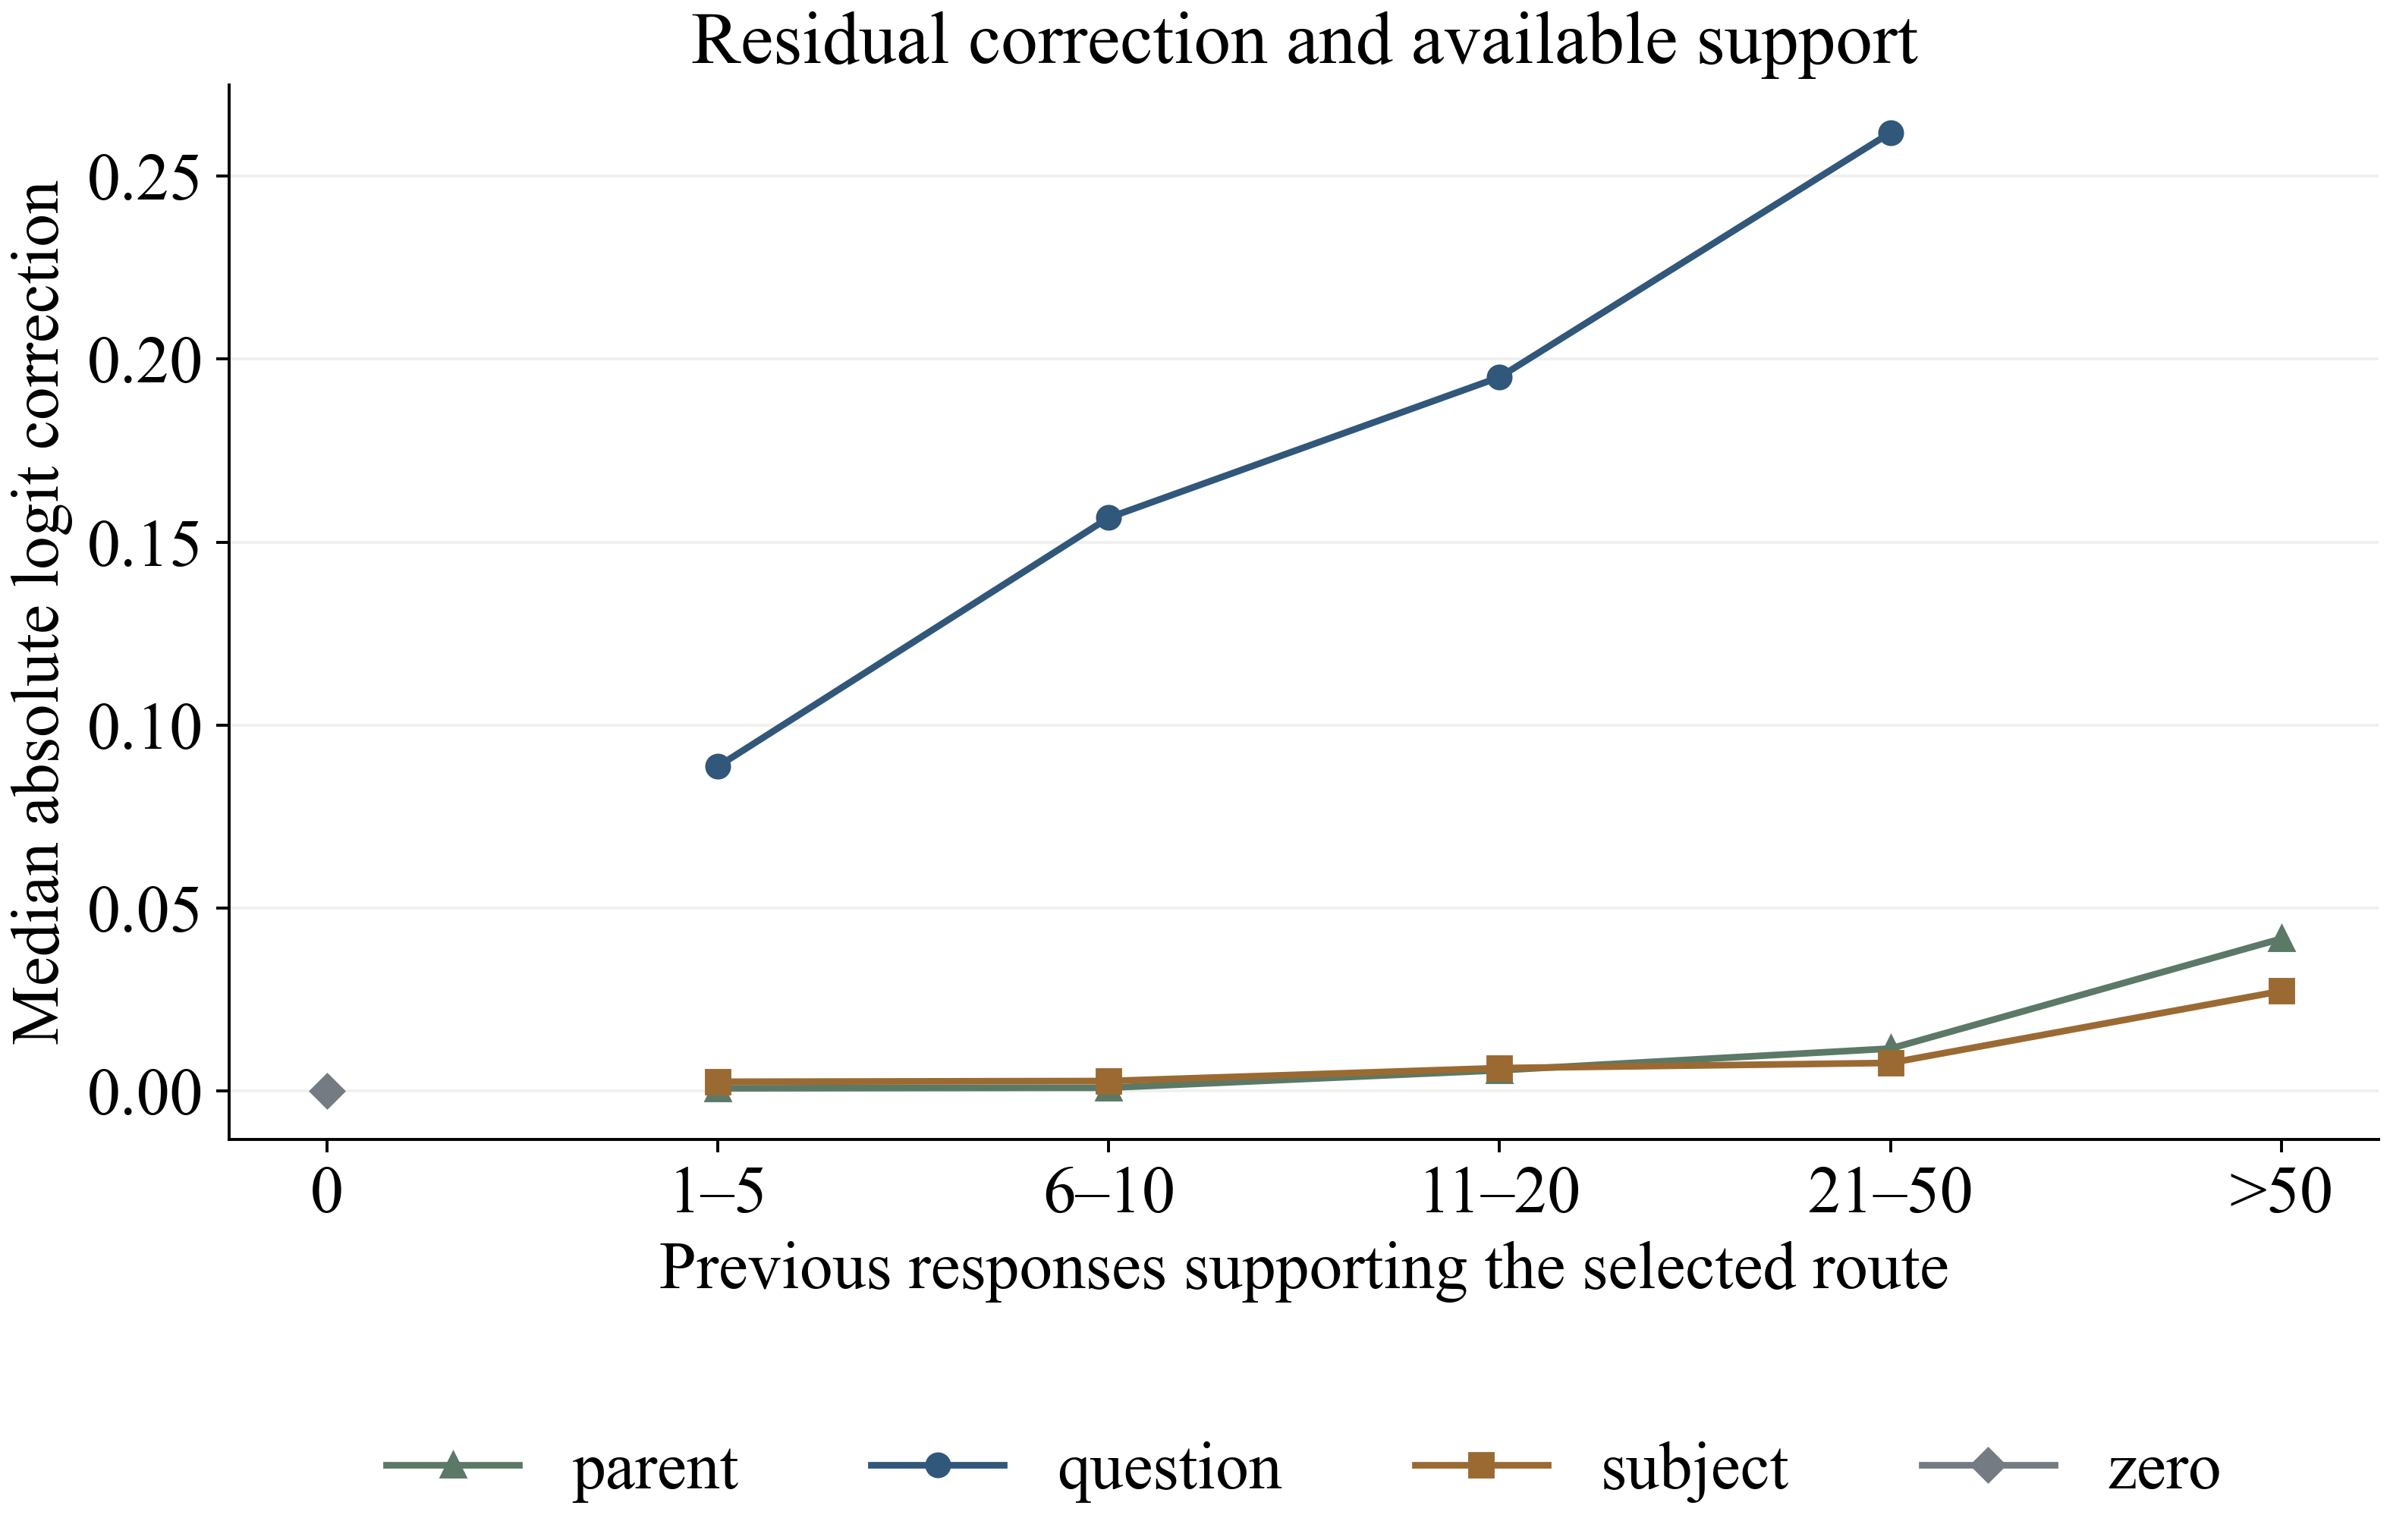

In [26]:
import joblib
features=pd.read_parquet(artifact_path("Data/features_primary.parquet")).set_index("AnswerId",drop=False)
mechanism_parts=[]
for fold in range(6):
    seed=pr["seeds"][0]
    ids=pd.read_parquet(artifact_path("Data")/f"round2_fitting_ids_seed{seed}_fold{fold}.parquet")
    ids=ids[ids.model.eq("AdaptiveMath-AI") & ids.component.eq("calibrator")].AnswerId
    block=features.loc[ids].reset_index(drop=True)
    assert block.DateAnswered.max()<pd.Timestamp(pr["calendar"]["outer_edges"][fold],tz="UTC")
    obj=joblib.load(artifact_path("Models")/f"round2_AdaptiveMath_AI_seed{seed}_fold{fold}.joblib")
    _,route=rm.reconstruct(obj,block)
    mechanism_parts.append(pd.concat([block[["AnswerId"]],route],axis=1).assign(fold=fold))
mechanism=pd.concat(mechanism_parts,ignore_index=True)
route_summary=mechanism.groupby(["fold","route"],dropna=False).agg(N=("AnswerId","size"),
    Median_support=("support_n","median"),Minimum_support=("support_n","min"),Maximum_support=("support_n","max"),
    Clipped_fraction=("clipped","mean"),Mean_abs_logit_correction=("correction",lambda s:s.abs().mean())).reset_index()
route_summary["Fraction"]=route_summary.N/route_summary.groupby("fold").N.transform("sum")
show_table(route_summary,"Route usage and support by monthly window",["fold","route"],width=4)
mechanism_summary=mechanism.assign(Support_band=pd.cut(mechanism.support_n,[-1,0,5,10,20,50,np.inf],
    labels=["0","1–5","6–10","11–20","21–50",">50"]))
curve=mechanism_summary.groupby(["route","Support_band"],observed=True).agg(N=("AnswerId","size"),
    Median_absolute_correction=("correction",lambda s:s.abs().median())).reset_index()
fig,ax=plt.subplots(figsize=(9,5.8),layout="constrained")
palette={"question":"#31577A","subject":"#9B6A32","parent":"#5B7966","zero":"#747B82"}
markers={"question":"o","subject":"s","parent":"^","zero":"D"}
for route,g in curve.groupby("route"):
    ax.plot(g.Support_band.cat.codes,g.Median_absolute_correction,label=route,color=palette.get(route,"#747B82"),
        marker=markers.get(route,"o"),linewidth=1.8)
ax.set_xticks(range(6),["0","1–5","6–10","11–20","21–50",">50"])
ax.set(xlabel="Previous responses supporting the selected route",ylabel="Median absolute logit correction")
ax.set_title("Residual correction and available support")
ax.spines[["top","right"]].set_visible(False);ax.grid(axis="y",alpha=.18)
ax.legend(loc="upper center",bbox_to_anchor=(.5,-.23),ncol=4,frameon=False)
save_canvas(fig,"adaptive_math_route_support")
del features

## Mechanistic conclusion
A residual-memory effect must be distinguished from a hierarchy effect. Final paired results in Notebook 06 do not establish an additional benefit from subject fallback or from the full model over Question_only. No real hierarchy values are missing in the selected cohort; robustness to missing keys is tested synthetically and is not described as an observed cohort improvement. The matched recent-rate and converged item-intercept controls bound what novelty can be claimed.